# BankAssist Triage — Intent Classification Modelling

## Objective

This notebook develops and evaluates the traditional machine learning intent classifier for the BankAssist Triage application.

The modelling stage uses the fixed train, validation, and test datasets prepared during the data preparation stage. The original dataset will not be re-split.

The workflow is:

**Train → TF-IDF → Classifier Training → Validation & Model Comparison → Model Selection → Final Test Evaluation**

The primary model-selection metric is **Macro F1**, complemented by accuracy and per-class performance metrics.


## Setup and Data Loading

This section imports the libraries required for modelling and evaluation, locates the prepared dataset files, and loads the predefined train, validation, and test splits.

In [1]:
from pathlib import Path

import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import matplotlib.pyplot as plt


In [2]:
Path.cwd()

WindowsPath('c:/Users/Jonny/Documents/Joaninha/EXEC MASTERS IN BUSINESS ANALYTICS AND AI/MLOps/bankassist-triage/notebooks')

### Load Predefined Data Splits

The modelling stage uses the train, validation, and test splits produced during the data preparation stage. These splits are kept unchanged to ensure consistency across the project and to avoid data leakage.

- **Training set:** used to fit the models.
- **Validation set:** used to compare model configurations and select the best-performing approach.
- **Test set:** reserved for the final unbiased evaluation of the selected model.

In [3]:
DATA_DIR = Path("../data/splits")

train_path = DATA_DIR / "train.csv"
validation_path = DATA_DIR / "validation.csv"
test_path = DATA_DIR / "test.csv"

print("Train:", train_path.exists())
print("Validation:", validation_path.exists())
print("Test:", test_path.exists())

Train: True
Validation: True
Test: True


In [4]:
train_df = pd.read_csv(train_path)
validation_df = pd.read_csv(validation_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

Train shape: (691, 2)
Validation shape: (148, 2)
Test shape: (149, 2)


In [5]:
print("Columns:", train_df.columns.tolist())

display(train_df.head())

Columns: ['text', 'label']


,text,label
0,can i order a second card?,getting_spare_card
1,what currencies can i use to add money to my a...,supported_cards_and_currencies
2,which credit card top-ups do you accept?,supported_cards_and_currencies
3,unable to use my american express with apple p...,apple_pay_or_google_pay
4,"i received my american express in apple pay, i...",apple_pay_or_google_pay


### Features and Target

The input feature (`X`) is the customer message stored in the `text` column, while the target variable (`y`) is the corresponding banking intent stored in the `label` column.

The same structure is maintained across the training, validation, and test sets.

In [6]:
X_train = train_df["text"]
y_train = train_df["label"]

X_validation = validation_df["text"]
y_validation = validation_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_validation))
print("Test samples:", len(X_test))
print("Number of classes:", y_train.nunique())

Training samples: 691
Validation samples: 148
Test samples: 149
Number of classes: 10


### Dataset Validation

The final reviewed dataset contains **988 observations across 10 intent classes**, distributed as follows:

- **Training:** 691 observations
- **Validation:** 148 observations
- **Test:** 149 observations

The predefined splits produced during the data preparation and quality review stage are used without further re-splitting.

In [7]:
classes = sorted(y_train.unique())

print("Classes:")
for label in classes:
    print("-", label)

Classes:
- apple_pay_or_google_pay
- beneficiary_not_allowed
- cancel_transfer
- card_about_to_expire
- card_payment_fee_charged
- change_pin
- getting_spare_card
- lost_or_stolen_phone
- supported_cards_and_currencies
- visa_or_mastercard


## Model Development

The modelling approach combines **TF-IDF (Term Frequency–Inverse Document Frequency)** for text feature extraction with **Logistic Regression** for multiclass intent classification.

TF-IDF transforms each customer message into a numerical feature vector based on the importance of words within the dataset. Logistic Regression then uses these features to estimate the probability of each of the 10 intent classes.

Two model configurations will be trained on the same training set and compared using the validation set:

- **Model A — Baseline:** TF-IDF using unigrams (single words) + Logistic Regression.
- **Model B — Extended:** TF-IDF using unigrams and bigrams (single words and two-word combinations) + Logistic Regression.

The models will be compared primarily using **Macro F1**. The test set will remain untouched during model selection and will only be used for the final evaluation of the selected model.

### Model A — Baseline: TF-IDF Unigrams + Logistic Regression

The baseline model uses a scikit-learn `Pipeline` combining:

1. **TF-IDF Vectorizer** with unigrams (`ngram_range=(1,1)`) to transform customer messages into numerical features.
2. **Logistic Regression** to perform multiclass intent classification.

Using a pipeline ensures that the same text transformation applied during training is consistently applied during validation, testing, and later inference.

In [8]:
model_a = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 1))),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

model_a

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

#### Model Training

Model A is trained exclusively on the **training set (691 observations)**. During training, the TF-IDF vectorizer learns the vocabulary and feature representation from the training messages, while Logistic Regression learns the relationship between these features and the 10 intent classes.

The validation and test sets are not used during model training.

In [9]:
model_a.fit(X_train, y_train)

print("Model A training completed.")

Model A training completed.


#### Validation Evaluation

Model A is evaluated on the **validation set (148 observations)**, which was not used during training.

The primary evaluation metric is **Macro F1**, as it calculates the F1-score independently for each intent class and gives equal importance to all 10 classes. **Accuracy** is also reported as a complementary overall performance metric.

The validation results will be used to compare candidate model configurations and select the model to be evaluated on the held-out test set.

In [10]:
y_val_pred_a = model_a.predict(X_validation)

model_a_macro_f1 = f1_score(
    y_validation,
    y_val_pred_a,
    average="macro"
)

model_a_accuracy = accuracy_score(
    y_validation,
    y_val_pred_a
)

print(f"Model A Validation Macro F1: {model_a_macro_f1:.4f}")
print(f"Model A Validation Accuracy: {model_a_accuracy:.4f}")

Model A Validation Macro F1: 0.9194
Model A Validation Accuracy: 0.9189


### Model B — Extended: TF-IDF Unigrams + Bigrams + Logistic Regression

Model B extends the baseline TF-IDF representation by including both **unigrams and bigrams** (`ngram_range=(1,2)`).

While unigrams represent individual words, bigrams capture combinations of two consecutive words. This may provide additional contextual information for banking intents where short expressions or word combinations help distinguish between classes.

The Logistic Regression classifier is kept unchanged so that the comparison with Model A isolates the effect of extending the TF-IDF feature representation.

In [11]:
model_b = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

model_b

Pipeline(steps=[('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

#### Model Training

Model B is trained on the same **691 training observations** used for Model A. The only change between the two models is the TF-IDF feature representation, which now includes both unigrams and bigrams.

Keeping the training data and classifier configuration unchanged allows the validation results to isolate the effect of adding bigram features.

In [12]:
model_b.fit(X_train, y_train)

print("Model B training completed.")

Model B training completed.


#### Validation Evaluation

Model B is evaluated on the same **148 validation observations** used for Model A.

The same evaluation metrics — **Macro F1** as the primary metric and **Accuracy** as a complementary metric — are used to ensure a consistent comparison between the two candidate configurations.

In [13]:
y_val_pred_b = model_b.predict(X_validation)

model_b_macro_f1 = f1_score(
    y_validation,
    y_val_pred_b,
    average="macro"
)

model_b_accuracy = accuracy_score(
    y_validation,
    y_val_pred_b
)

print(f"Model B Validation Macro F1: {model_b_macro_f1:.4f}")
print(f"Model B Validation Accuracy: {model_b_accuracy:.4f}")

Model B Validation Macro F1: 0.9026
Model B Validation Accuracy: 0.9054


## Model Comparison and Selection

The two candidate configurations are compared using the validation set. **Macro F1 is the primary model-selection metric**, while accuracy is reported as a complementary metric.

Model A, using TF-IDF unigrams, achieved a higher validation Macro F1 than Model B, which included both unigrams and bigrams. Therefore, adding bigram features did not improve validation performance for this dataset.

Based on the predefined model-selection criterion, **Model A is selected as the preferred configuration for final evaluation**.

In [14]:
model_comparison = pd.DataFrame({
    "Model": ["Model A", "Model B"],
    "TF-IDF Features": ["Unigrams", "Unigrams + Bigrams"],
    "Validation Macro F1": [model_a_macro_f1, model_b_macro_f1],
    "Validation Accuracy": [model_a_accuracy, model_b_accuracy]
})

model_comparison

,Model,TF-IDF Features,Validation Macro F1,Validation Accuracy
0,Model A,Unigrams,0.919369,0.918919
1,Model B,Unigrams + Bigrams,0.902560,0.905405


## Final Test Evaluation

After model selection using the validation set, Model A is evaluated on the held-out **test set (149 observations)**.

The test set has not been used for model training or model selection. It therefore provides an independent estimate of the selected model's generalization performance on unseen data.

The final evaluation includes:

- **Macro F1** as the primary performance metric;
- **Accuracy** as a complementary overall metric;
- **Precision, Recall, and F1-score by intent class**;
- **Confusion Matrix** to identify which intents are most frequently confused.

The test set is used only for this final evaluation.

In [15]:
y_test_pred = model_a.predict(X_test)

test_macro_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

print(f"Final Test Macro F1: {test_macro_f1:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")

Final Test Macro F1: 0.9674
Final Test Accuracy: 0.9664


### Per-Class Performance

To complement the aggregate metrics, precision, recall, and F1-score are examined for each of the 10 intent classes.

This analysis helps determine whether the strong overall performance is consistent across intents or whether specific classes remain more difficult to classify.

In [16]:
print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4
    )
)

                                precision    recall  f1-score   support

       apple_pay_or_google_pay     1.0000    1.0000    1.0000        13
       beneficiary_not_allowed     0.8824    0.9375    0.9091        16
               cancel_transfer     1.0000    1.0000    1.0000        17
          card_about_to_expire     0.9333    0.9333    0.9333        15
      card_payment_fee_charged     0.9130    1.0000    0.9545        21
                    change_pin     1.0000    0.9231    0.9600        13
            getting_spare_card     1.0000    0.8462    0.9167        13
          lost_or_stolen_phone     1.0000    1.0000    1.0000        12
supported_cards_and_currencies     1.0000    1.0000    1.0000        14
            visa_or_mastercard     1.0000    1.0000    1.0000        15

                      accuracy                         0.9664       149
                     macro avg     0.9729    0.9640    0.9674       149
                  weighted avg     0.9684    0.9664    0.9664 

### Confusion Matrix

The confusion matrix provides a detailed view of the classification errors by comparing the actual intent with the intent predicted by the selected model.

This analysis helps identify which banking intents are most frequently confused and provides additional context beyond the aggregate performance metrics.

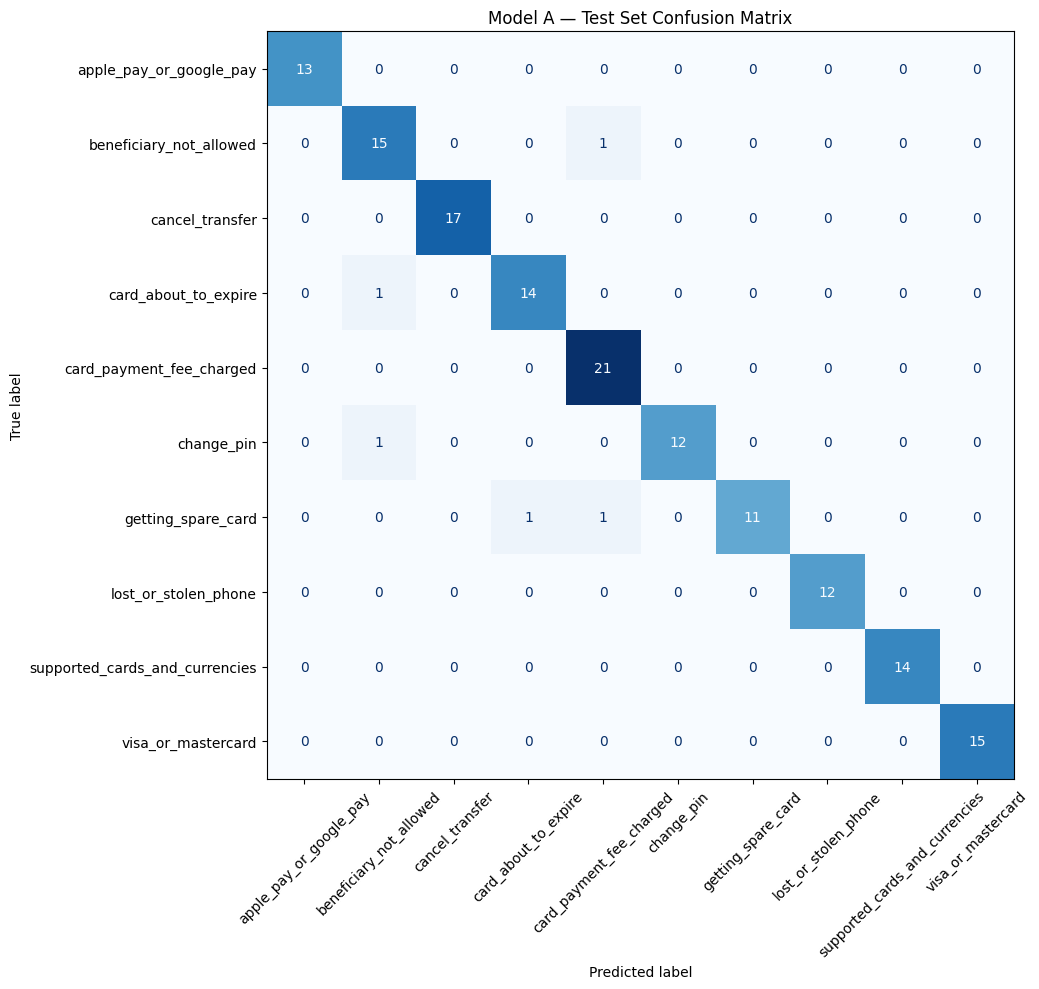

In [17]:
cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False
)

plt.title("Model A — Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

### Results Interpretation

Model A demonstrated strong performance on the held-out test set, achieving a **Macro F1 of 0.9674** and an **Accuracy of 0.9664**.

Performance was particularly strong across the 10 banking intents, with five classes achieving an F1-score of 1.0000. The lowest F1-scores were observed for `beneficiary_not_allowed` (0.9091) and `getting_spare_card` (0.9167).

The confusion matrix shows only **5 misclassified observations out of 149 test cases**. The errors were distributed across a small number of card- and beneficiary-related intents rather than concentrated in a single class.

Overall, the results indicate that the TF-IDF unigram representation combined with Logistic Regression provides strong classification performance on this dataset. However, given the relatively small test set, these results should be interpreted as evidence of performance on the current dataset rather than as a guarantee of equivalent performance on real-world banking messages.

### Misclassification Analysis

The misclassified test observations are examined individually to understand whether the errors reflect genuine model limitations, semantic ambiguity, or potential data-quality issues.

In [18]:
misclassified = test_df.loc[
    y_test != y_test_pred,
    ["text", "label"]
].copy()

misclassified["predicted_label"] = y_test_pred[y_test != y_test_pred]

misclassified

,text,label,predicted_label
0,Nants ingonyama bagithi baba,card_about_to_expire,beneficiary_not_allowed
30,why can't i buy cryptocurrency on the app?,beneficiary_not_allowed,card_payment_fee_charged
49,how do i go about ordering another card?,getting_spare_card,card_about_to_expire
99,how much would an extra card cost?,getting_spare_card,card_payment_fee_charged
138,why is a payment i made reverted back to my ac...,change_pin,beneficiary_not_allowed


#### Error Analysis Findings

The final model misclassified **5 out of 149 test observations**.

A qualitative review suggests that the errors are not all of the same nature. Some observations represent plausible model errors, such as confusion between `getting_spare_card` and other card-related intents. Other observations contain text that appears semantically ambiguous or weakly aligned with the assigned intent.

These observations are retained in the test set and the reported evaluation metrics remain unchanged. The analysis is therefore used to understand model limitations and potential data-quality considerations, rather than to modify the test data after evaluation.

## Modelling Conclusion

Two TF-IDF + Logistic Regression configurations were evaluated using the predefined validation set.

- **Model A — Unigrams:** Validation Macro F1 = **0.9194**
- **Model B — Unigrams + Bigrams:** Validation Macro F1 = **0.9026**

Based on the predefined primary selection metric, **Model A was selected as the final classifier**.

On the held-out test set, Model A achieved:

- **Macro F1:** 0.9674
- **Accuracy:** 0.9664
- **Correct classifications:** 144 out of 149
- **Misclassifications:** 5 out of 149

The results show that the simpler unigram-based representation outperformed the unigram-plus-bigram configuration on the validation set. Error analysis also identified a small number of test observations that may reflect semantic ambiguity or data-quality limitations, in addition to genuine model classification errors.

The selected Model A pipeline can now be handed over to the MLOps stage for experiment tracking, model registration, and subsequent integration with the prediction API.

## Reproducibility check

In another computer, we restarted the kernel and ran all cells in order using the committed
`data/splits/` files. The run completed without relying on variables
from an earlier session.

- Train / validation / test rows: 691 / 148 / 149
- Model A validation macro F1: [0.9194]
- Model B validation macro F1: [0.9026]

Model A remained the winner on validation macro F1.